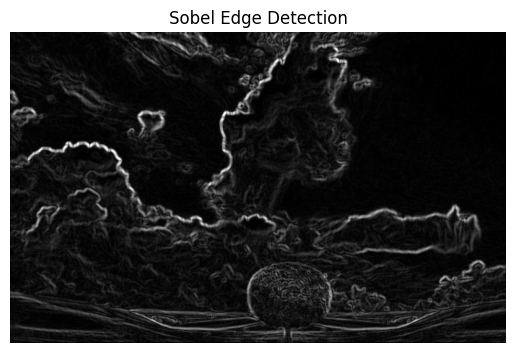

In [1]:
# ===================== IMPORT PACKAGES =====================

# Syntax:
# import module_name
# Purpose: Imports the OpenCV library for image processing.
import cv2

# Syntax:
# import module_name as alias_name
# Purpose: Imports matplotlib for displaying images.
import matplotlib.pyplot as plt


# ===================== READ IMAGE =====================

# Syntax:
# variable = cv2.imread("image_path")

# Parameter:
# "image_path" -> Name or location of the image file.

# Return Value:
# Returns the image as a NumPy array.
# Returns None if the image is not found.

src = cv2.imread("source.jpg")


# Check whether the image is loaded successfully.
if src is None:
    print("Error: Cannot find 'source.jpg'")

else:

    # ===================== APPLY GAUSSIAN BLUR =====================

    # Syntax:
    # output = cv2.GaussianBlur(src, ksize, sigmaX)

    # Parameters:
    # src    -> Input image.
    # ksize  -> Kernel size (3,3).
    # sigmaX -> Standard deviation in X direction.

    # Purpose:
    # Removes noise from the image before edge detection.

    blur = cv2.GaussianBlur(src, (3, 3), 0)


    # ===================== CONVERT TO GRAYSCALE =====================

    # Syntax:
    # output = cv2.cvtColor(src, code)

    # Parameters:
    # src  -> Input image.
    # code -> Type of color conversion.

    # Here:
    # cv2.COLOR_BGR2GRAY converts the image
    # from BGR format to Grayscale.

    gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)


    # ===================== APPLY SOBEL OPERATOR =====================

    # Syntax:
    # output = cv2.Sobel(src,
    #                    ddepth,
    #                    dx,
    #                    dy,
    #                    ksize,
    #                    scale,
    #                    delta,
    #                    borderType)

    # Parameters:
    # src        -> Input grayscale image.
    # ddepth     -> Depth of output image (cv2.CV_16S).
    # dx         -> Order of derivative in x direction.
    # dy         -> Order of derivative in y direction.
    # ksize      -> Size of Sobel kernel.
    # scale      -> Scale factor.
    # delta      -> Value added to the result.
    # borderType -> Border extrapolation method.


    # ===================== HORIZONTAL EDGES =====================

    # dx = 1, dy = 0
    # Finds horizontal gradients (changes in x direction).

    grad_x = cv2.Sobel(gray,
                       cv2.CV_16S,
                       1,
                       0,
                       ksize=3,
                       scale=1,
                       delta=0,
                       borderType=cv2.BORDER_DEFAULT)


    # ===================== VERTICAL EDGES =====================

    # dx = 0, dy = 1
    # Finds vertical gradients (changes in y direction).

    grad_y = cv2.Sobel(gray,
                       cv2.CV_16S,
                       0,
                       1,
                       ksize=3,
                       scale=1,
                       delta=0,
                       borderType=cv2.BORDER_DEFAULT)


    # ===================== CONVERT TO ABSOLUTE VALUES =====================

    # Syntax:
    # output = cv2.convertScaleAbs(src)

    # Parameter:
    # src -> Input image.

    # Purpose:
    # Converts pixel values to absolute values
    # and changes them to unsigned 8-bit integers.

    abs_grad_x = cv2.convertScaleAbs(grad_x)
    abs_grad_y = cv2.convertScaleAbs(grad_y)


    # ===================== COMBINE BOTH GRADIENTS =====================

    # Syntax:
    # output = cv2.addWeighted(src1,
    #                          alpha,
    #                          src2,
    #                          beta,
    #                          gamma)

    # Parameters:
    # src1  -> First image.
    # alpha -> Weight of first image.
    # src2  -> Second image.
    # beta  -> Weight of second image.
    # gamma -> Scalar added to the sum.

    # Formula:
    # Output = (src1 × alpha) + (src2 × beta) + gamma

    grad = cv2.addWeighted(abs_grad_x,
                           0.5,
                           abs_grad_y,
                           0.5,
                           0)


    # ===================== DISPLAY THE RESULT =====================

    # Syntax:
    # plt.imshow(image, cmap='gray')

    # Parameter:
    # image -> Image to display.
    # cmap  -> Color map.

    plt.imshow(grad, cmap='gray')
    plt.title("Sobel Edge Detection")
    plt.axis("off")
    plt.show()